# Introduction to Derivatives and Integrals 
### (a numerical approach) ###

This tutorial can be deployed in [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChemAI-Lab/Math4Chem/blob/main/lecture_notes/Notes/Coding/derivatives_and_integrals.ipynb)

Let's load the basic libraries that we will use.

In [4]:
# import numpy and matplotlib and pyplot
# code here! 
import numpy as np
import matplotlib.pyplot as plt

1. **Numpy** ([paper](https://www.nature.com/articles/s41586-020-2649-2.pdf))is by far one of the most amazing tools in scientific computations. Numpy is the foundation for many Python libraries. 
2. **Matplotlib** ([paper](https://ieeexplore.ieee.org/document/4160265)) is used extensively for plotting. [Tutorials](https://matplotlib.org/stable/tutorials/index.html)

## Derivatives ##

Last week we cover in class the definition of the derivative of a function,   [![Download PDF](https://img.shields.io/badge/Download_PDF-Click_Here-blue.svg)](https://github.com/ChemAI-Lab/Math4Chem/raw/main/lecture_notes/Notes/Derivatives_notes.pdf)

$$
f'(x) = \frac{d f(x)}{dx} = \frac{d y}{dx} = \displaystyle \lim_{\Delta x \to 0} \frac{f(x + \Delta x) - f(x)}{\Delta x}
$$


1.  Define a function in Python,
$$
f(x) = 10 + \left(\frac{x}{10}\right)^3e^{(\frac{x}{10})^2}
$$

In [18]:
# in Python.
def f(x):
    #code here you can use np.power, np.exp, etc.
    x = x/10
    u_cube = np.power(x,3)
    u_square = np.power(x,2)
    y = 10 + u_cube*np.exp(u_square)
    return y

2. Plot the function using Matplotlib

In [5]:
# https://numpy.org/doc/stable/reference/generated/numpy.linspace.html
x_grid = np.linspace(-10, 10, 25)
print('what is x_grid?: ')
print(x_grid)

# uncomment this to see the difference for plt.scatter and plt.plot
# x_grid = np.array([-1,0,1])

# evaluate our function
y = f(x_grid)

print('what is x?: ', type(x_grid))
print('what is f?: ', type(f))
print('what is y?: ', type(y))

what is x_grid?: 
[-10.          -9.16666667  -8.33333333  -7.5         -6.66666667
  -5.83333333  -5.          -4.16666667  -3.33333333  -2.5
  -1.66666667  -0.83333333   0.           0.83333333   1.66666667
   2.5          3.33333333   4.16666667   5.           5.83333333
   6.66666667   7.5          8.33333333   9.16666667  10.        ]
what is x?:  <class 'numpy.ndarray'>
what is f?:  <class 'function'>
what is y?:  <class 'numpy.ndarray'>


Text(0.5, 0, 'x')

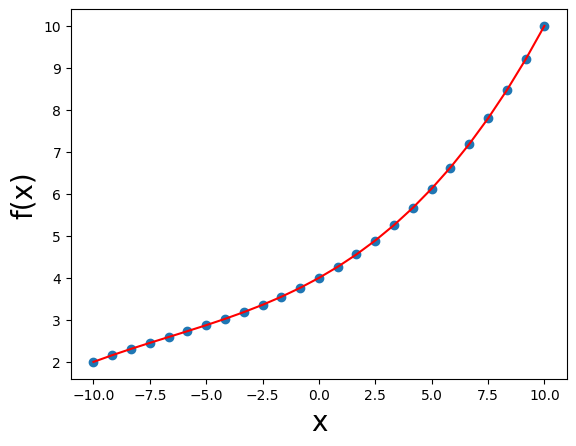

In [19]:
# let's plot the function f(x)
# exercise
# what is the difference between plt.plot(x,y) and plt.scatter(x,y)

plt.plot(x_grid,y,color='red')
plt.scatter(x_grid,y)
plt.ylabel('f(x)',fontsize=20)
plt.xlabel('x', fontsize=20)

Instead of using the general definition of "derivative", let's use the **two-point formula**  to compute the derivative of a function, 
$$
\frac{d f(x)}{dx} \approx \frac{f(x + h) - f(x - h)}{2h}
$$

In [20]:
def df_dx(x,h):
    # code here, you can use f(x+h) and f(x-h)
    dy = (f(x+h) - f(x-h))/(2*h)
    return dy 

h = 0.1
dy_values = df_dx(x_grid,h)
print('x', x_grid.shape)
print('df/dx', dy_values.shape)

x (25,)
df/dx (25,)


What is the derivative of $f(x)$?
$$ 
\frac{d f(x)}{dx} = \frac{d f(x)}{dx} \left ( 10 + \left(\frac{x}{10}\right)^3e^{(\frac{x}{10})^2} \right )
$$
$$
\frac{d f(x)}{dx} = \left (\frac{3x^2}{1000} + \frac{x^4}{5000} \right )e^{(\frac{x}{10})^2}
 = \left( \tfrac{3}{10}\left(\tfrac{x}{10}\right)^2 + \tfrac{1}{5}\left(\tfrac{x}{10}\right)^4 \right)  e^{\left(\tfrac{x}{10}\right)^2}.
$$

<!-- ```python
def df_dx_true(x):
    x2 = np.power(x, 2)
    x4 = np.power(x, 4)
    print(type(x))
    e = np.exp(x2/100)
    y = 3*x2/(10**3) + x4/50000
    y = y*e
    return y
``` -->

Using python define a function that represent the **true** derivative of $f(x)$. <br>
For this we may need these extra operations in Python,
1. power function:  <br> `x**2` or `np.power(x,2)`
2. exponential function: <br> `np.exp(x)`

In [21]:
def df_dx_true(x):
    # code here!
    u = x/10
    u_square = np.power(u,2)
    u_quad = np.power(u,4)
    
    dy = ((3/10)*u_square + (1/5)*u_quad) * np.exp(u_square)
    return dy

3. Let's compare the true derivative vs the numerically one using the two-point formula.<br>
   Use a ```h = 0.1``` for the two-point formula.

Text(0.5, 0, 'x')

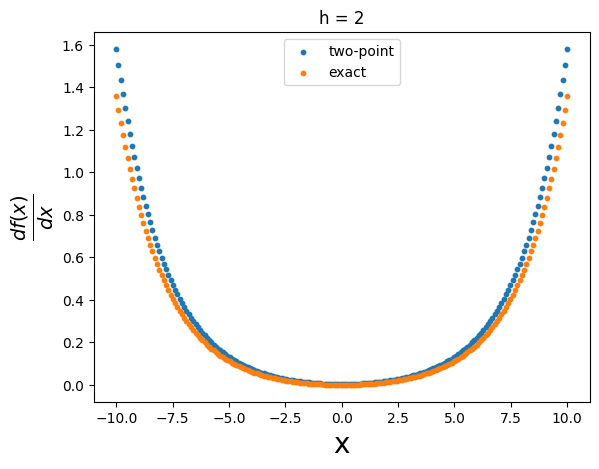

In [25]:
x = np.linspace(-10,10,200)
h = 2

# evaluate both methods
df_num = df_dx(x,h) # two-point differentiation
df_true = df_dx_true(x) # exact derivative

plt.title(f"h = {h}")
plt.scatter(x,df_num, s=10, label = 'two-point')
plt.scatter(x, df_true, s=10, label='exact')
plt.legend()


plt.ylabel(r'$\frac{df(x)}{dx}$', fontsize=20)
plt.xlabel('x', fontsize=20)

Let's ask an LLM to help us generate an animation code as a function of `h`


Add a new code cell after the derivative comparison. Using the existing f, df_dx, and df_dx_true functions, create a Matplotlib animation showing how the numerical derivative changes as \(h\) decreases from 5 to \(10^{-2}\). Keep the exact derivative fixed, display the current \(h\) and show the animation inline in Google Colab using FuncAnimation and HTML(animation.to_jshtml()). Keep the axes fixed and do not modify previous cells. Use an ipywidgets.FloatLogSlider for  \(h\).
```

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display, clear_output
import ipywidgets as widgets

# Values of h decrease logarithmically from 5 to 10^-2.
h_values = np.geomspace(5, 1e-2, 40)
df_exact = df_dx_true(x)
df_numerical = [df_dx(x, h_value) for h_value in h_values]

# Use all frames to choose fixed axis limits.
all_derivatives = np.concatenate([df_exact, *df_numerical])
y_min, y_max = np.min(all_derivatives), np.max(all_derivatives)
y_margin = 0.05 * (y_max - y_min)

# Automatic animation.
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x, df_exact, color='black', linewidth=2, label='exact')
numerical_line, = ax.plot([], [], color='red', linewidth=2, label='two-point')
title = ax.set_title('')
ax.set_xlim(x.min(), x.max())
ax.set_ylim(y_min - y_margin, y_max + y_margin)
ax.set_xlabel('x', fontsize=14)
ax.set_ylabel(r'$\frac{df(x)}{dx}$', fontsize=18)
ax.grid(alpha=0.3)
ax.legend()

def update_animation(frame):
    h_value = h_values[frame]
    numerical_line.set_data(x, df_numerical[frame])
    title.set_text(f'Numerical derivative with h = {h_value:.3g}')
    return numerical_line, title

animation = FuncAnimation(
    fig, update_animation, frames=len(h_values), interval=150, blit=False
)
plt.close(fig)
display(HTML(animation.to_jshtml()))

# Interactive plot controlled by a logarithmic slider.
slider_output = widgets.Output()
h_slider = widgets.FloatLogSlider(
    value=1, base=10, min=-2, max=np.log10(5), step=0.02,
    description='h:', continuous_update=True, readout_format='.3g',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='700px')
)

def update_slider_plot(change=None):
    h_value = h_slider.value
    with slider_output:
        clear_output(wait=True)
        slider_fig, slider_ax = plt.subplots(figsize=(8, 5))
        slider_ax.plot(x, df_exact, color='black', linewidth=2, label='exact')
        slider_ax.plot(x, df_dx(x, h_value), color='red', linewidth=2,
                       label='two-point')
        slider_ax.set_title(f'Numerical derivative with h = {h_value:.3g}')
        slider_ax.set_xlim(x.min(), x.max())
        slider_ax.set_ylim(y_min - y_margin, y_max + y_margin)
        slider_ax.set_xlabel('x', fontsize=14)
        slider_ax.set_ylabel(r'$\frac{df(x)}{dx}$', fontsize=18)
        slider_ax.grid(alpha=0.3)
        slider_ax.legend()
        plt.show()
        plt.close(slider_fig)

h_slider.observe(update_slider_plot, names='value')
display(h_slider, slider_output)
update_slider_plot()

FloatLogSlider(value=1.0, description='h:', layout=Layout(width='700px'), max=0.6989700043360189, min=-2.0, st…

Output()

$\bullet$ What is the error in the numerical derivatives? 
$$
RMSE = \sum_i^N (y_i - \hat{y}_i)^2,
$$
where $\hat{y}_i$ is the true value

In [31]:
# compute the error between both methods
def f_rmse(a,b):
    # use numpy functions to compute the root mean square error
    # np.sqrt, np.mean, np.power
    # code here!
    rmse = np.sqrt(np.mean(np.power(a-b,2)))
    return rmse

RMSE =  0.07216321830939433


Text(0.5, 0, 'x')

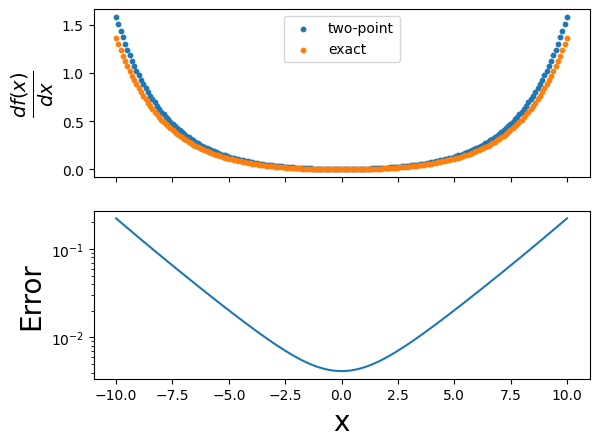

In [ ]:
dy_values = df_dx(x,h)
dy_true = df_dx_true(x)
rmse_val = f_rmse(dy_values, dy_true)
print('RMSE = ', rmse_val)

# Figure with two subplots
_, (ax1, ax2) = plt.subplots(2, 1, sharex=True)
# Analytical and numerical derivatives
ax1.scatter(x, dy_values, s=10, label='two-point')
ax1.scatter(x, dy_true, s=10, label='exact')
ax1.legend()
ax1.set_ylabel(r'$\frac{df(x)}{dx}$', fontsize=20)
# ax1.set_xlabel('x', fontsize=20)

error = dy_values - dy_true
# Error plot
# ax2.plot(x, error)
# ax2.semilogy(x, np.abs(error)) 
ax2.set_ylabel(r"Error", fontsize=20)
ax2.set_xlabel('x', fontsize=20)

**Extra exercises** <br>
Try plotting the error for other values of h to see what will be the value to get a good approximation of derivative. 

## Integration ##
In this part of the tutorial, we will cover numerical integration. 
$$
\int_a^b f(x)dx = \displaystyle \lim_{h \to 0}  \sum_i^N f(\varepsilon_i) h
$$
where ```h``` is the width of the *"rectangle"*.


The goal of this tutorial is to compute the integral of the function,
$$
f(x) = 10 + \left(\frac{x}{10}\right)^3e^{(\frac{x}{10})^2}
$$
in the interval -10 to 10. 

$$
\int_{-10}^{10}f(x) dx = \int_{-11}^{11} 10 + \left(\frac{x}{10}\right)^3e^{(\frac{x}{10})^2}dx = 220
$$

1. What is the value of $\int_{-11}^{11}f(x) dx$ ?  (try to solve this at home) <br>
Tips. <br>
a. use change of variables. <br>
b. use integration by parts.

Text(0, 0.5, '$f(x)$')

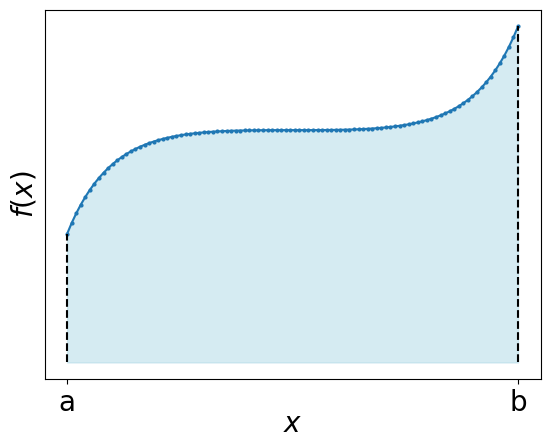

In [41]:
# define the limits
a = -11
b = 11

# evaluate f(x) for plotting
x = np.linspace(a, b, 100)
y = f(x)

plt.plot(x, y,marker='o',markersize=2)
plt.fill_between(x, y, color='lightblue', alpha=0.5)
plt.vlines(a, 0, f(a), color='k', ls='--')
plt.vlines(b, 0, f(b), color='k', ls='--')

plt.xticks([a, b], ['a', 'b'], fontsize=20)
plt.xlabel(r'$x$', fontsize=20, labelpad=-5)
plt.yticks([])
plt.ylabel(r'$f(x)$', fontsize=20)

1. Compute the integral of $f(x)$ using a single "rectangle".
2. What height shall we choose? 

In [ ]:
# formula for the area of a rectangle
# area is height times width
# code here!
area = (b - a) * max(y)
print('integral value is ', area)

integral value is  318.19673759594053


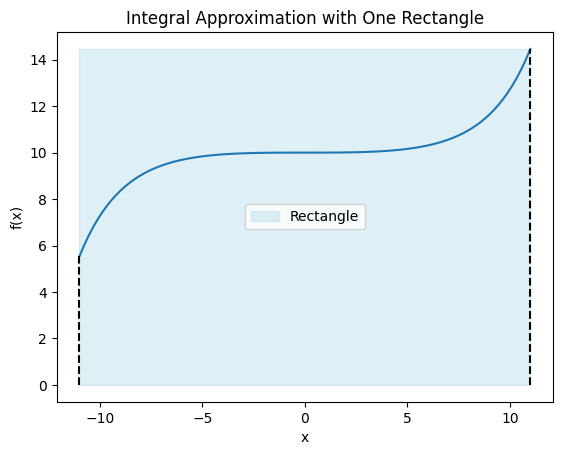

In [43]:
height = f(b)
plt.plot(x, y)
plt.fill_between([a, b], [height, height], color='lightblue',
                 alpha=0.4, step="post", label="Rectangle")

# Draw vertical lines for rectangle edges
plt.vlines(a, 0, f(a), color='k', ls='--')
plt.vlines(b, 0, f(b), color='k', ls='--')

plt.title("Integral Approximation with One Rectangle")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()

2. Compute the integral of $f(x)$ using two "rectangles".

In [44]:
a = -11
b = 11

n_points = 2
h = (b-a)/n_points

# first rectangle
xl = a + h
yl = f(xl)
area_l = yl*(h)

# second rectangle
xr = a + 2*h
yr = f(xr)
area_r = yr*(h)

# total area
area = area_l + area_r
    
print('integral value is ', area)

integral value is  269.09836879797024


Text(0, 0.5, 'f(x)')

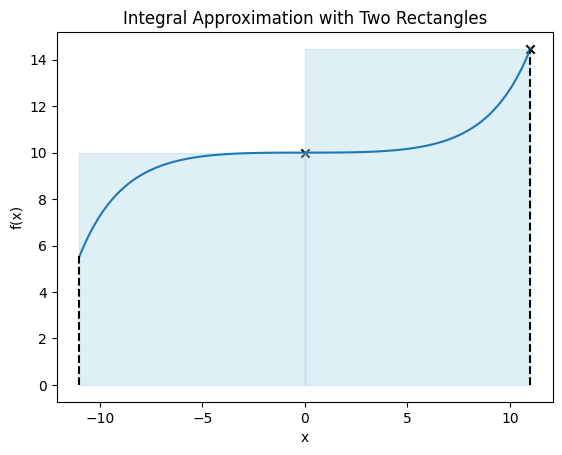

In [46]:

plt.plot(x, y)
# first rectangle
plt.scatter(xl, yl, color='k',marker='x')
plt.fill_between([a, xl], [f(xl), f(xl)], color='lightblue',
                 alpha=0.4, step="post")
# second rectangle
plt.scatter(xr, yr, color='k', marker='x')
plt.fill_between([xl,b], [f(b), f(b)], color='lightblue',
                 alpha=0.4, step="post")

# Draw vertical lines for rectangle edges
plt.vlines(a, 0, f(a), color='k', ls='--')
plt.vlines(b, 0, f(b), color='k', ls='--')

plt.title("Integral Approximation with Two Rectangles")
plt.xlabel("x")
plt.ylabel("f(x)")
# plt.legend()

area =  12.18032624040594
area =  18.747716887584403
area =  21.022237979637943
area =  21.7725635217005
area =  21.975412714949325
area =  21.999999999999993
area =  22.02458728505066
area =  22.227436478299484
area =  22.977762020362043
area =  25.252283112415583
-------------------
total area =  210.18032624040592
-------------------


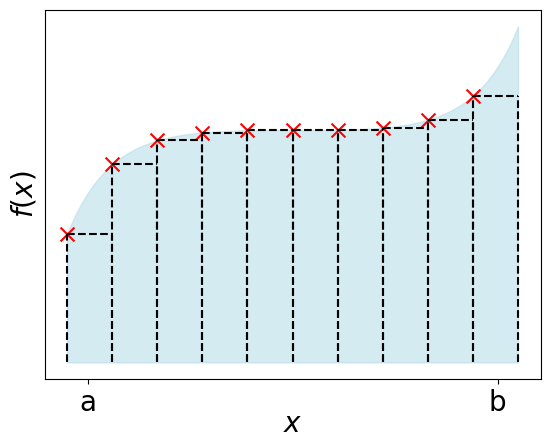

In [49]:
x = np.linspace(a, b, 100)
y = f(x)
plt.fill_between(x, y, color='lightblue', alpha=0.5)

n_points = 10 # play with the number of point to see how the approximation improves
x = np.linspace(a, b, n_points+1)
h = x[1] - x[0]


area = 0
for xi in x[:-1]:
    yi = f(xi)
    ai = yi*(h)
    print('area = ', ai)
    plt.scatter(xi, f(xi), color='red', marker='x',s=100)
    plt.vlines(xi+h, 0, f(xi), color='k', ls='--')
    plt.vlines(xi, 0, f(xi), color='k', ls='--')
    plt.hlines(f(xi), xi, xi+h, color='k', ls='--')
    area += ai
plt.xticks([-10, 10], ['a', 'b'], fontsize=20)
plt.xlabel(r'$x$', fontsize=20, labelpad=-5)
plt.yticks([])
plt.ylabel(r'$f(x)$', fontsize=20)

print('-------------------')
print('total area = ', area)
print('-------------------')

How does the integral value changes with the number of points?

In [51]:
def f_integral_approximation(n):
    x = np.linspace(a, b, n+1)
    h = x[1] - x[0]
    area = 0
    for xi in x[:-1]:
        yi = f(xi)
        ai = yi*(h)
        area += ai
    return area

In [ ]:
# (1) create an array of n values from 1 to 0 using numpy arange function
n_grid = np.arange(1, 51)
# (2) for each n point, compute the integral approximation using 
# the rectangle method and store the results in an array

int_values = []
for ni in n_grid:
    int_values.append(f_integral_approximation(ni))


Text(0.5, 0, 'n')

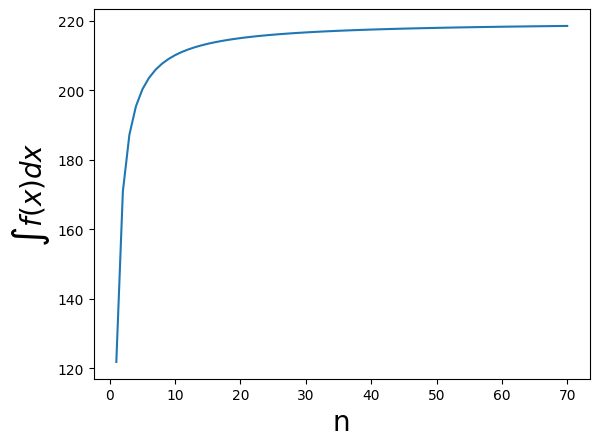

In [63]:
# plot 
plt.plot(n_grid, int_values)
plt.ylabel(r"$\int f(x) dx$", fontsize=20)
plt.xlabel("n", fontsize=20)

## Midpoint Riemann Sum

Approximates the definite integral of a function by summing the areas of rectangles whose heights are determined by the function's value at the midpoint of each subinterval

area =  68.38157289453207
area =  73.33333333333333
area =  78.2850937721346
-------------------
total area =  220.0
-------------------


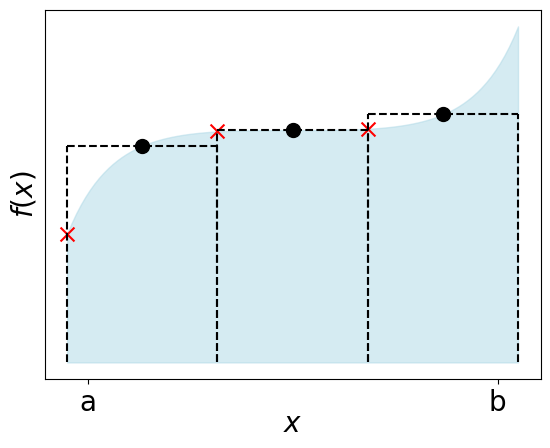

In [64]:
x = np.linspace(a, b, 100)
y = f(x)
plt.fill_between(x, y, color='lightblue', alpha=0.5)

n_points = 3
x = np.linspace(a, b, n_points+1)
h = x[1] - x[0]


area = 0
for xi in x[:-1]:
    xj = xi + h/2
    yj = f(xj)
    aj = yj*(h)
    print('area = ', aj)
    plt.scatter(xi, f(xi), color='red', marker='x', s=100)
    plt.scatter(xj, yj, color='k', s=100)
    plt.vlines(xi, 0, f(xj), color='k', ls='--')
    plt.vlines(xi + h, 0, f(xj), color='k', ls='--')
    plt.hlines(f(xj), xi, xi+h, color='k', ls='--')
    area += aj
plt.xticks([-10, 10], ['a', 'b'], fontsize=20)
plt.xlabel(r'$x$', fontsize=20, labelpad=-5)
plt.yticks([])
plt.ylabel(r'$f(x)$', fontsize=20)
    
print('-------------------')
print('total area = ', area) 
print('-------------------')

Let's try
$$
f(x) = \cos(5x)^2+x^2
$$

$$
\int_{-1}^{1} \cos(5x)^2+x^2 dx \approx 1.6123
$$

In [72]:
def f2(x):
    # code here!
    y = np.cos(5*x)**2 + np.power(x,2)
    return y

Text(0, 0.5, '$f(x)$')

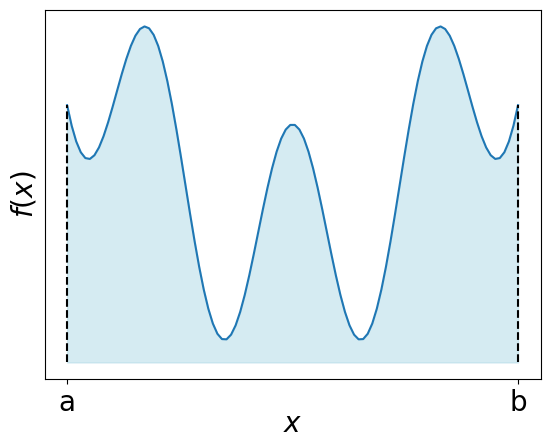

In [73]:
a = -1
b = 1

x = np.linspace(a, b, 100)
y = f2(x)

plt.plot(x, y)
plt.fill_between(x, y, color='lightblue', alpha=0.5)
plt.vlines(a, 0, f2(a), color='k', ls='--')
plt.vlines(b, 0, f2(b), color='k', ls='--')

plt.xticks([-1, 1], ['a', 'b'], fontsize=20)
plt.xlabel(r'$x$', fontsize=20, labelpad=-5)
plt.yticks([])
plt.ylabel(r'$f(x)$', fontsize=20)


area =  0.09039139219018105
area =  0.09214940486575882
area =  0.12358176589175127
area =  0.14107938128640113
area =  0.11568348871456298
area =  0.059710210028461
area =  0.01542716563546016
area =  0.016192819222653324
area =  0.05578686008338515
area =  0.09412912809451862
area =  0.09412912809451862
area =  0.05578686008338509
area =  0.016192819222653268
area =  0.015427165635460191
area =  0.05971021002846104
area =  0.11568348871456298
area =  0.14107938128640116
area =  0.12358176589175122
area =  0.09214940486575882
area =  0.0903913921901811
-------------------
total area =  1.608263232026267
-------------------


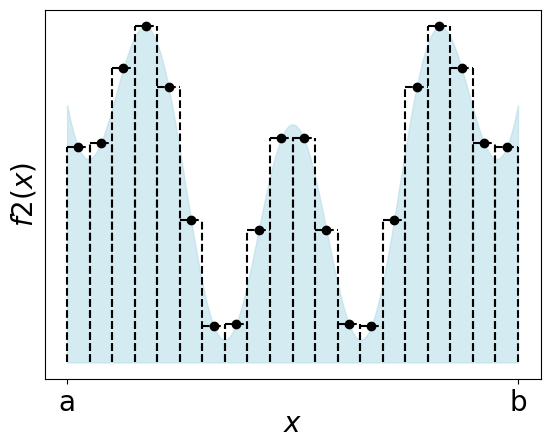

In [76]:
x = np.linspace(a, b, 200)
y = f2(x)

plt.fill_between(x, y, color='lightblue', alpha=0.5)

n_points = 20
x = np.linspace(a, b, n_points+1)
h = x[1] - x[0]
area = 0
for xi in x[:-1]:
    xj = xi + h/2
    yj = f2(xj)
    aj = yj*(h)
    print('area = ', aj)
    plt.scatter(xj, yj, color='k')
    plt.vlines(xi, 0, f2(xj), color='k', ls='--')
    plt.vlines(xi + h, 0, f2(xj), color='k', ls='--')
    plt.hlines(f2(xj), xi, xi+h, color='k', ls='--')
    area += aj
plt.xticks([-1, 1], ['a', 'b'], fontsize=20)
plt.xlabel(r'$x$', fontsize=20, labelpad=-5)
plt.yticks([])
plt.ylabel(r'$f2(x)$', fontsize=20)
# plt.savefig('integral_10.png', dpi=260)

print('-------------------')
print('total area = ', area)
print('-------------------')